c:\Users\15195\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


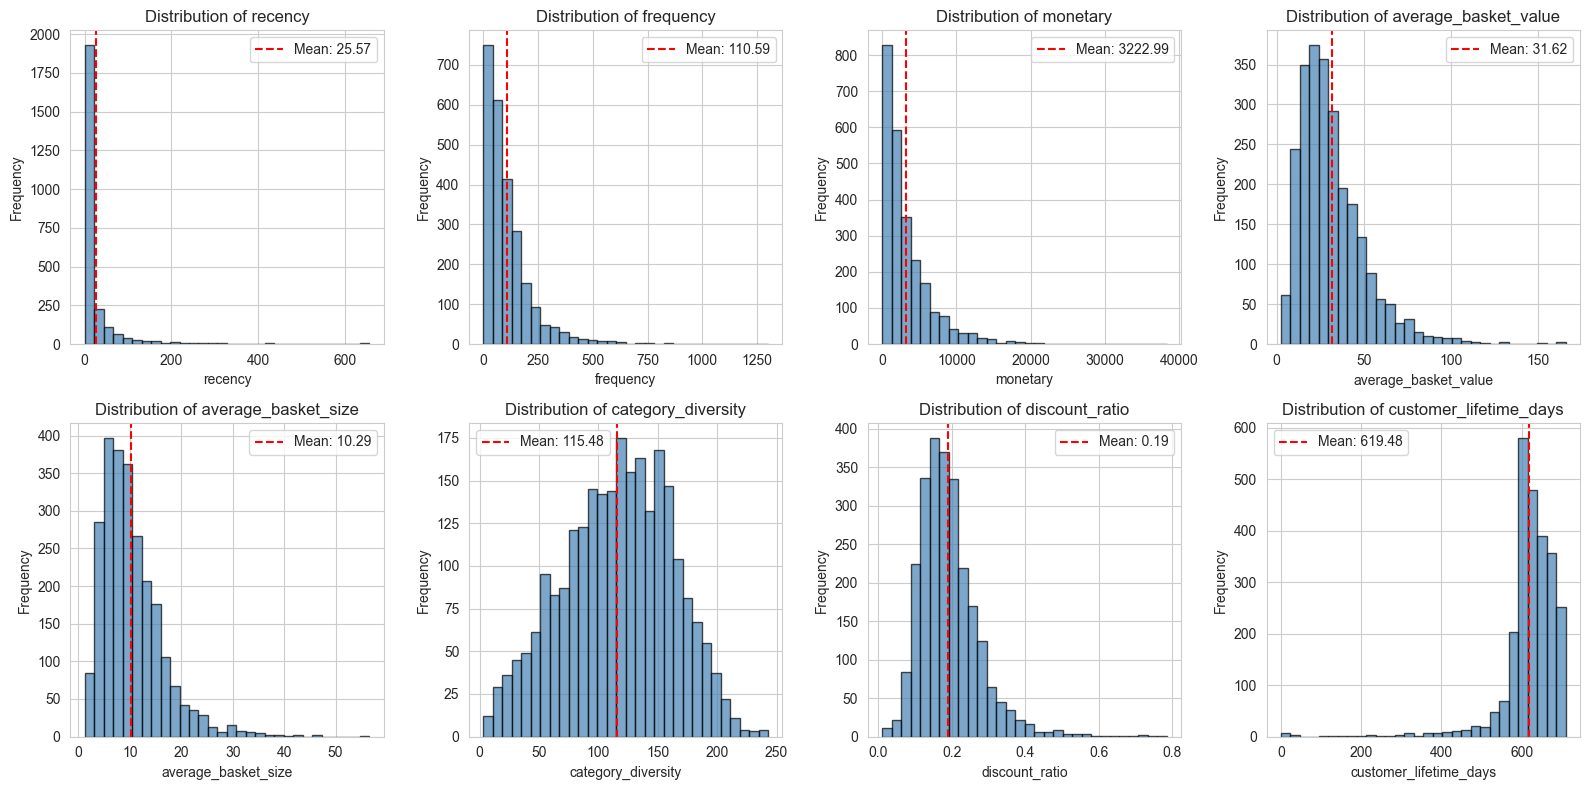

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

household_features_for_clustering = pd.read_csv(
    r"C:\Users\15195\Desktop\coding part\dataset preparation\household_features_for_clustering.csv"
)
# The style of the illustration
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 10

# List the 8 features that require illustration.
dist_features = [
    'recency', 
    'frequency', 
    'monetary', 
    'average_basket_value',
    'average_basket_size', 
    'category_diversity', 
    'discount_ratio', 
    'customer_lifetime_days'
]

# 2 rows x 4 columns of sub-figures
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(dist_features):
    axes[i].hist(household_features_for_clustering[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].axvline(household_features_for_clustering[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {household_features_for_clustering[col].mean():.2f}')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.savefig('figure1_distribution_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

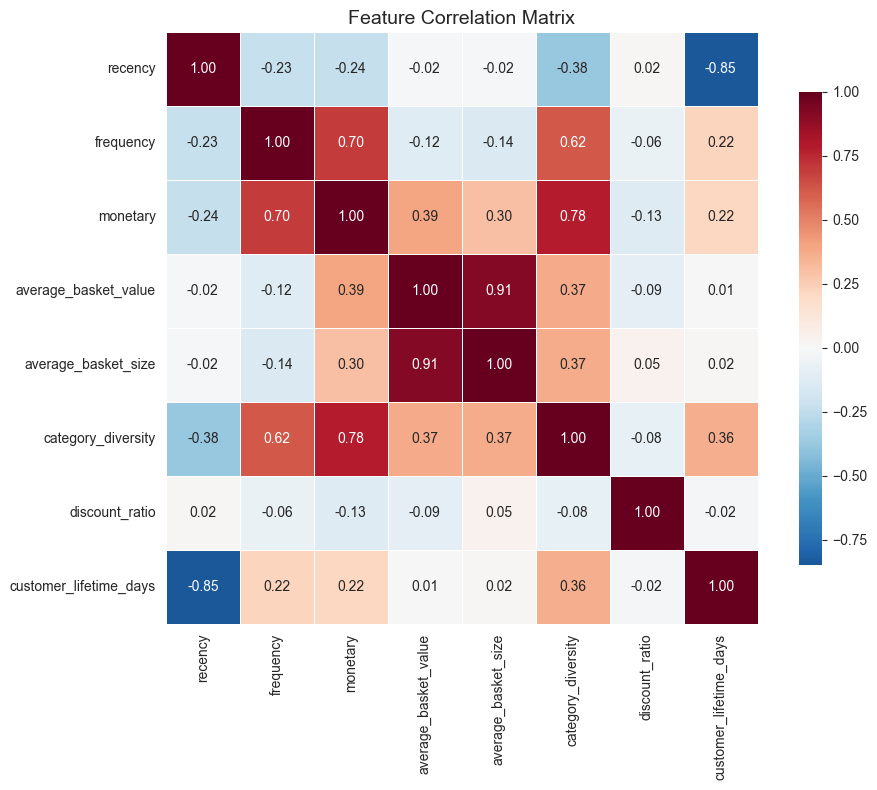

In [ ]:
import seaborn as sns
import pandas as pd

# Calculate the correlation coefficient matrix for 8 features
corr_features = [
    'recency', 
    'frequency', 
    'monetary', 
    'average_basket_value',
    'average_basket_size', 
    'category_diversity', 
    'discount_ratio', 
    'customer_lifetime_days'
]

corr_matrix = household_features_for_clustering[corr_features].corr()

# Draw a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,           # Display the values
    fmt='.2f',            # Display with two decimal places
    cmap='RdBu_r',        # Red-blue color scheme (red = positively correlated, blue = negatively correlated)
    center=0,             # White = 0
    square=True,          # Square grid
    linewidths=0.5,       # Grid lines
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('figure2_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

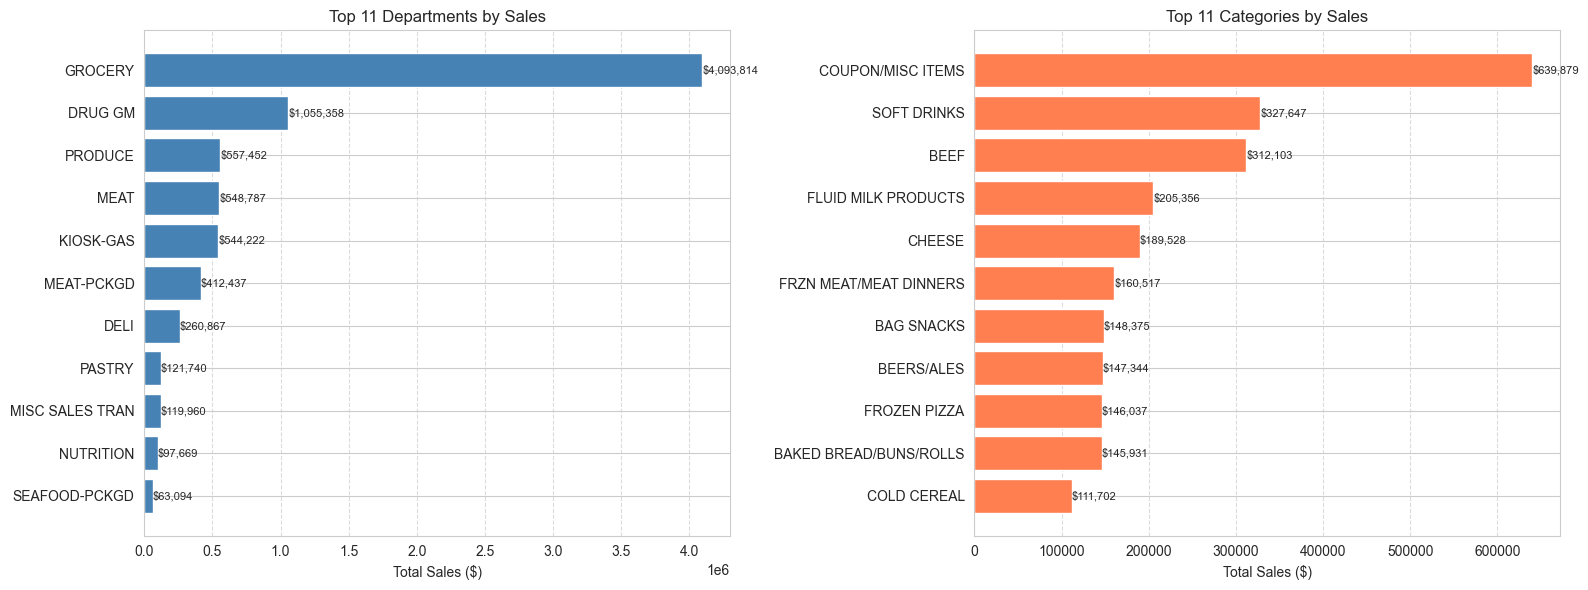

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

top11_dept = pd.read_csv(r"C:\Users\15195\Desktop\coding part\EDA part\top11_departments.csv")
top11_cat = pd.read_csv(r"C:\Users\15195\Desktop\coding part\EDA part\top11_categories.csv")

# Create a sub-chart with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 11 departments
dept_sorted = top11_dept.sort_values('total_sales', ascending=True)
axes[0].barh(dept_sorted['DEPARTMENT'], dept_sorted['total_sales'], color='steelblue')
axes[0].set_xlabel('Total Sales ($)')
axes[0].set_title('Top 11 Departments by Sales', fontsize=12)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Mark specific values at the end of the bars
for i, v in enumerate(dept_sorted['total_sales']):
    axes[0].text(v + 500, i, f'${v:,.0f}', va='center', fontsize=8)

# Top 11 categories
cat_sorted = top11_cat.sort_values('total_sales', ascending=True)
axes[1].barh(cat_sorted['COMMODITY_DESC'], cat_sorted['total_sales'], color='coral')
axes[1].set_xlabel('Total Sales ($)')
axes[1].set_title('Top 11 Categories by Sales', fontsize=12)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

for i, v in enumerate(cat_sorted['total_sales']):
    axes[1].text(v + 200, i, f'${v:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('figure3_top11_sales_barh.png', dpi=300, bbox_inches='tight')
plt.show()